In [1]:
import os
import sys
import pandas as pd
import joblib

sys.path.insert(0, os.path.abspath("../../src"))
from pipeline import run_etl, DOMINIOS
from modeling import seed, scoring, get_confusion_matrix, cv_repeated_kfold, cv_kfold, graficar_curvas_roc_multiclase, print_scores,nested_cross_validation_multi,compare_datasets_wilcoxon
df_tabla_0_imp, df_tabla_1_imp, df_mean, df_median = run_etl("../../.env")

Descargando datos desde GitHub...
Hojas cargadas: 125
Tabla 0 (escolaridad baja) : 36
Tabla 1 (escolaridad alta) : 81
No determinadas            : 8
df_tabla_0 crudo : (36, 32)
df_tabla_1 crudo : (81, 29)

 Imputando nulos...
--- Perfil nulos Tabla 0 ---
                                         nulos  %_nulos dtype  n_unicos
fluidez_verbal_semantica                    23    63.89   str         4
matrices                                    12    33.33   str         4
imagenes_sobrepuestas                       11    30.56   str         3
stroop_interferencia                         9    25.00   str         4
material_verbal_complejo                     6    16.67   str         3
denominacion                                 5    13.89   str         1
stroop_palabra                               4    11.11   str         4
stroop_color                                 4    11.11   str         4
atencion_sostenida_visual                    4    11.11   str         4
evocacion_diferida       

In [2]:
#Features para el modelo
DOMINIOS_COGNITIVOS = list(DOMINIOS.keys())
features = [col for col in df_mean.columns if col != "dc"]

X_mean = df_mean[features]
y_mean = pd.to_numeric(df_mean["dc"], errors='coerce').fillna(-1).astype(int)

X_median = df_median[features]
y_median = pd.to_numeric(df_median["dc"], errors='coerce').fillna(-1).astype(int)


In [3]:
#Cargar modelo
model_package_lr = joblib.load('../../models/modelo_logistic_regression_diagnostico.joblib')
model_package_rf = joblib.load('../../models/modelo_random_forest_diagnostico.joblib')
model_package_svm_lineal = joblib.load('../../models/modelo_svm_lineal_diagnostico.joblib')
model_package_svm_rbf = joblib.load('../../models/modelo_svm_rbf_diagnostico.joblib')

In [4]:
models = {
    'Logistic Regression': model_package_lr,
    'Random Forest': model_package_rf,
    'SVM Lineal': model_package_svm_lineal,
    'SVM RBF': model_package_svm_rbf
}

Evaluando modelo: Logistic Regression...
Evaluando modelo: Random Forest...
Evaluando modelo: SVM Lineal...
Evaluando modelo: SVM RBF...

Resultados de la comparación entre Media y Mediana (Prueba de Wilcoxon)


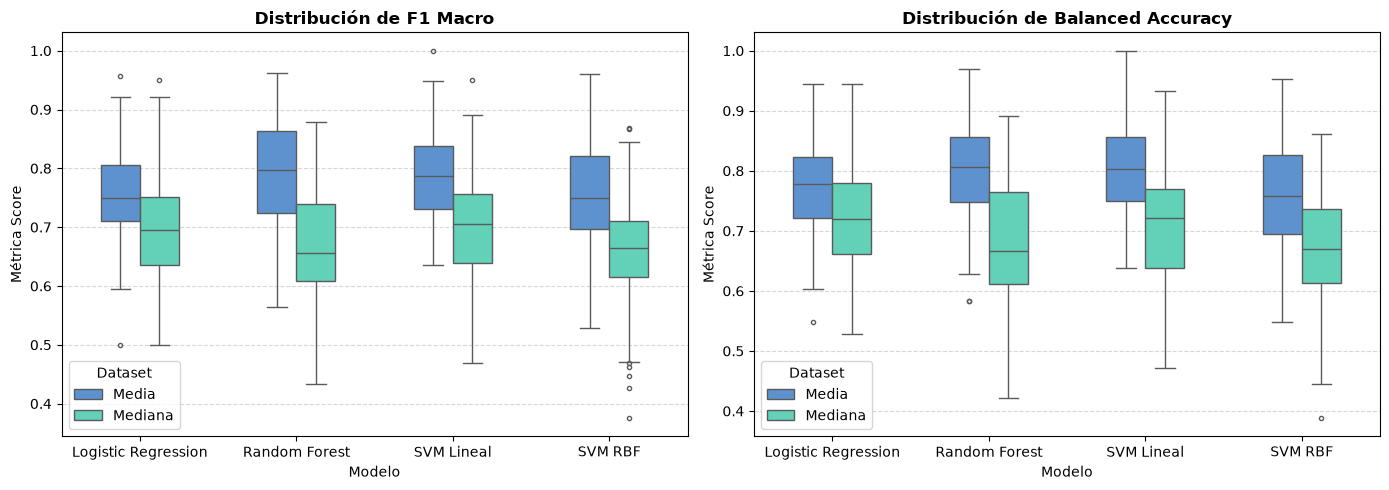

,Modelo,Métrica,Media (Dataset Media),Media (Dataset Mediana),Diferencia (Media - Mediana),Mediana de diferencias,Estadístico,p-valor,Significativo (alpha=0.05),Conclusión
0,Logistic Regression,F1 Macro,0.758408,0.696086,0.062322,0.061196,618.0,6.867299e-10,Sí,Diferencia significativa a favor de Media
1,Logistic Regression,Balanced Accuracy,0.777573,0.716518,0.061055,0.055556,515.5,5.738553e-11,Sí,Diferencia significativa a favor de Media
2,Random Forest,F1 Macro,0.788862,0.663969,0.124893,0.127495,229.0,2.917296e-15,Sí,Diferencia significativa a favor de Media
3,Random Forest,Balanced Accuracy,0.797908,0.679155,0.118753,0.112698,209.0,3.999358e-15,Sí,Diferencia significativa a favor de Media
4,SVM Lineal,F1 Macro,0.788270,0.699860,0.088410,0.091413,248.5,2.980629e-14,Sí,Diferencia significativa a favor de Media
5,SVM Lineal,Balanced Accuracy,0.802770,0.709672,0.093098,0.087121,131.0,2.271540e-15,Sí,Diferencia significativa a favor de Media
6,SVM RBF,F1 Macro,0.748806,0.659670,0.089135,0.081193,256.0,1.496979e-14,Sí,Diferencia significativa a favor de Media
7,SVM RBF,Balanced Accuracy,0.754341,0.670326,0.084015,0.080628,245.0,1.716028e-14,Sí,Diferencia significativa a favor de Media


In [5]:
compare_datasets_wilcoxon(models, X_mean, y_mean, X_median, y_median, cv_repeated_kfold, None, True)